# 01 — Exploratory Data Analysis


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from pathlib import Path
from scipy import stats

In [7]:
# Define paths for raw data and plots
RAW = Path('../data/raw')
PLOTS = Path('../outputs/plots')
PLOTS.mkdir(parents=True, exist_ok=True)
# Load datasets
genres_v2    = pd.read_csv(RAW / 'dataset_of_songs/genres_v2.csv', low_memory=False)
spotify_2023 = pd.read_csv(RAW / 'spotify_2023/spotify_data_12_20_2023.csv', low_memory=False)
audio_apr_2019    = pd.read_csv(RAW / 'spotify_audio_features/SpotifyAudioFeaturesApril2019.csv')
audio_nov_2018     = pd.read_csv(RAW / 'spotify_audio_features/SpotifyAudioFeaturesNov2018.csv')
sp_tracks    = pd.read_csv(RAW / 'spotify_tracks/dataset.csv', low_memory=False)
ultimate     = pd.read_csv(RAW / 'ultimate_spotify_tracks/SpotifyFeatures.csv')

datasets = {
    'genres_v2'              : genres_v2,
    'spotify_data_2023'      : spotify_2023,
    'audio_features_apr2019' : audio_apr_2019,
    'audio_features_nov2018' : audio_nov_2018,
    'spotify_tracks'         : sp_tracks,
    'ultimate_spotify_tracks': ultimate,
}


In [8]:
# Audio features common across all datasets
AUDIO_FEATURES = [
    'danceability', 'energy', 'loudness', 'speechiness',
    'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo'
]

In [9]:
# Check data types of each dataset
for name, df in datasets.items():
    print(f'\n{"_"*65}')
    print(f'\n📊📊📊 DATASET : {name}')
    print(f'\n{"_"*65}')
    print(df.dtypes.to_string())


_________________________________________________________________

📊📊📊 DATASET : genres_v2

_________________________________________________________________
danceability        float64
energy              float64
key                   int64
loudness            float64
mode                  int64
speechiness         float64
acousticness        float64
instrumentalness    float64
liveness            float64
valence             float64
tempo               float64
type                    str
id                      str
uri                     str
track_href              str
analysis_url            str
duration_ms           int64
time_signature        int64
genre                   str
song_name               str
Unnamed: 0          float64
title                   str

_________________________________________________________________

📊📊📊 DATASET : spotify_data_2023

_________________________________________________________________
album_id                 str
album_name               str



_________________________________________________________________

📊📊📊 DATASET  : genres_v2

_________________________________________________________________

 Shape: 42,305 rows x 22 cols

 Columns & Data Types:
  Column                                   Dtype
  ---------------------------------------------
  danceability                           float64
  energy                                 float64
  key                                      int64
  loudness                               float64
  mode                                     int64
  speechiness                            float64
  acousticness                           float64
  instrumentalness                       float64
  liveness                               float64
  valence                                float64
  tempo                                  float64
  type                                       str
  id                                         str
  uri                                        str
  

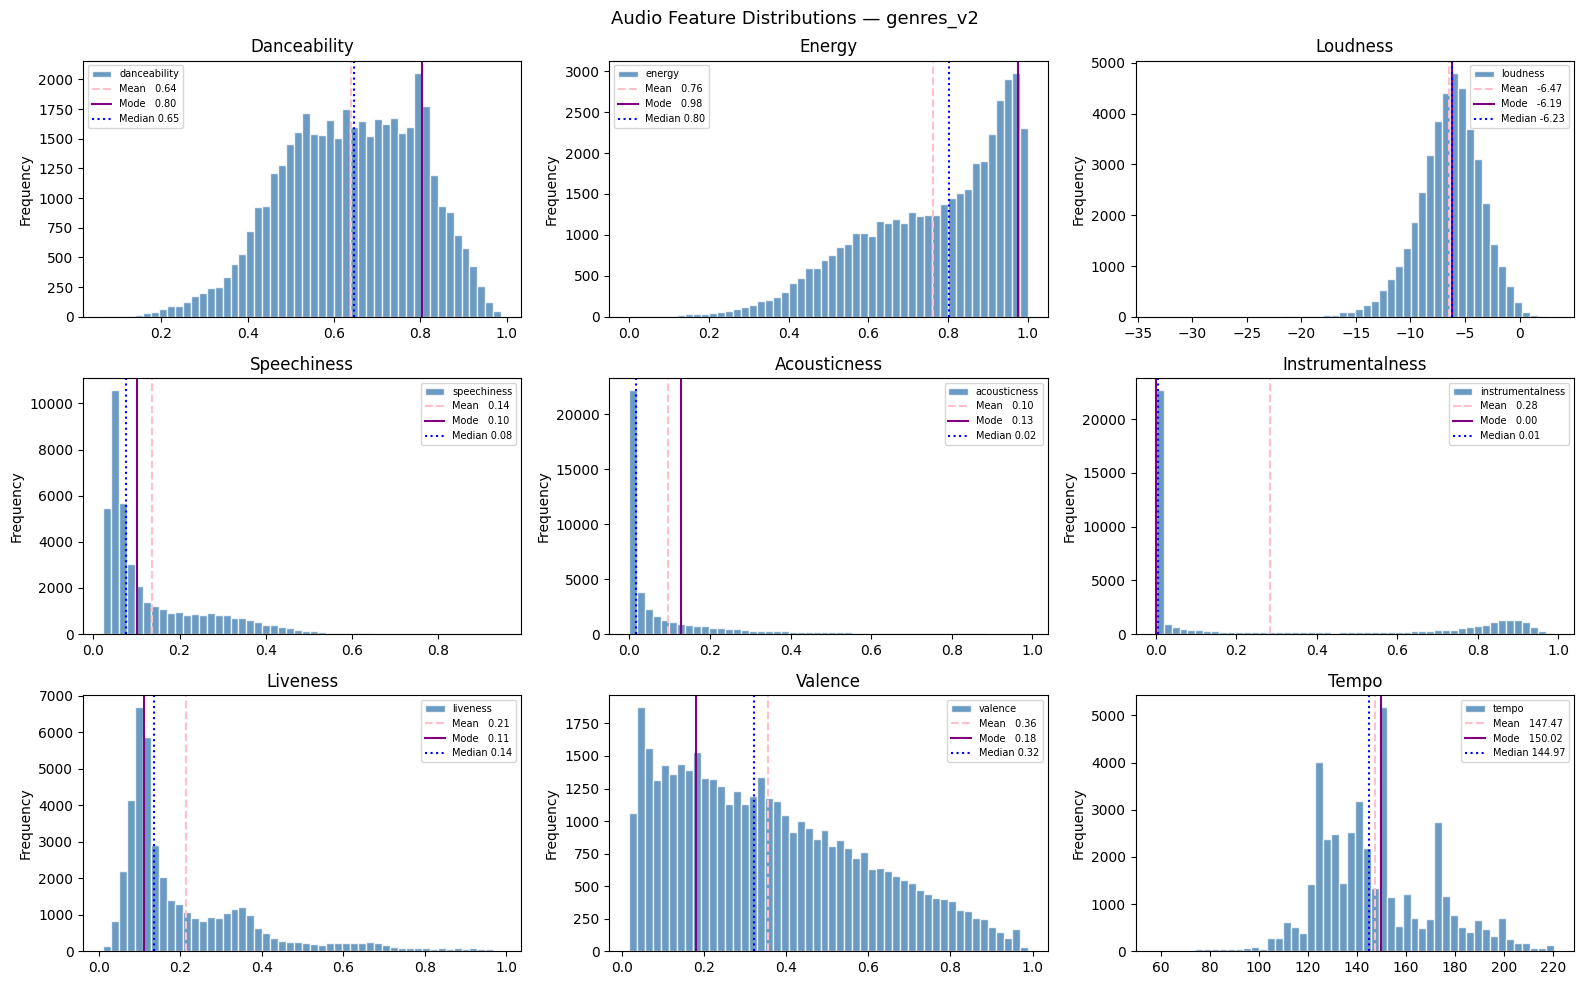

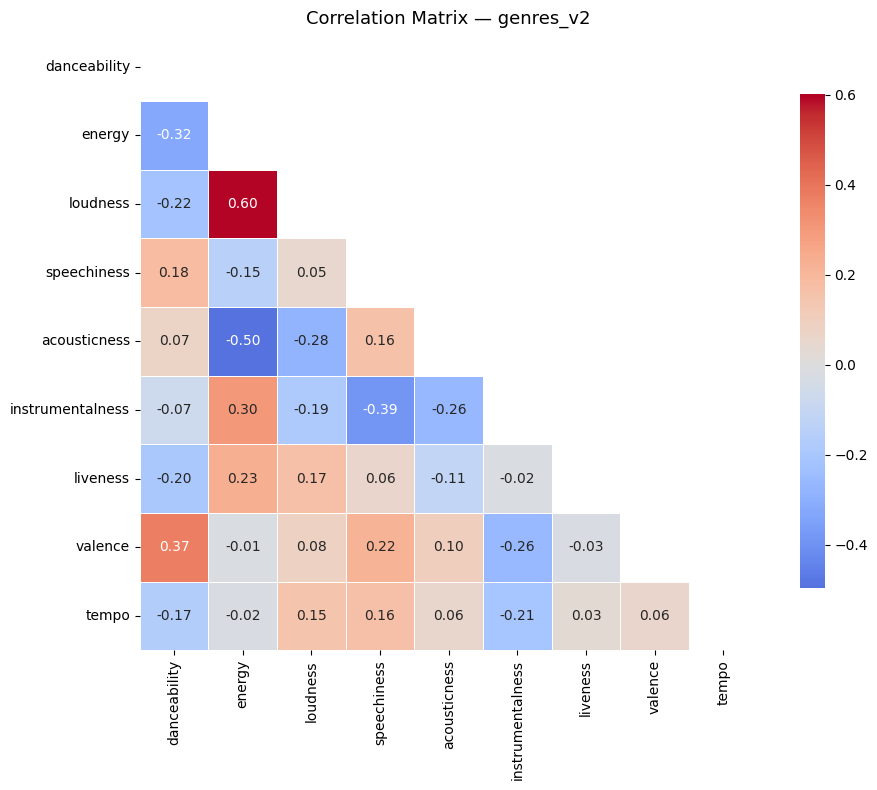


─────────────────────────────────────────────────────────────────


_________________________________________________________________

📊📊📊 DATASET  : spotify_data_2023

_________________________________________________________________

 Shape: 375,141 rows x 49 cols

 Columns & Data Types:
  Column                                   Dtype
  ---------------------------------------------
  album_id                                   str
  album_name                                 str
  album_popularity                         int64
  album_type                                 str
  artists                                    str
  artist_0                                   str
  artist_1                                   str
  artist_2                                   str
  artist_3                                   str
  artist_4                                   str
  artist_id                                  str
  duration_sec                           float64
  label                

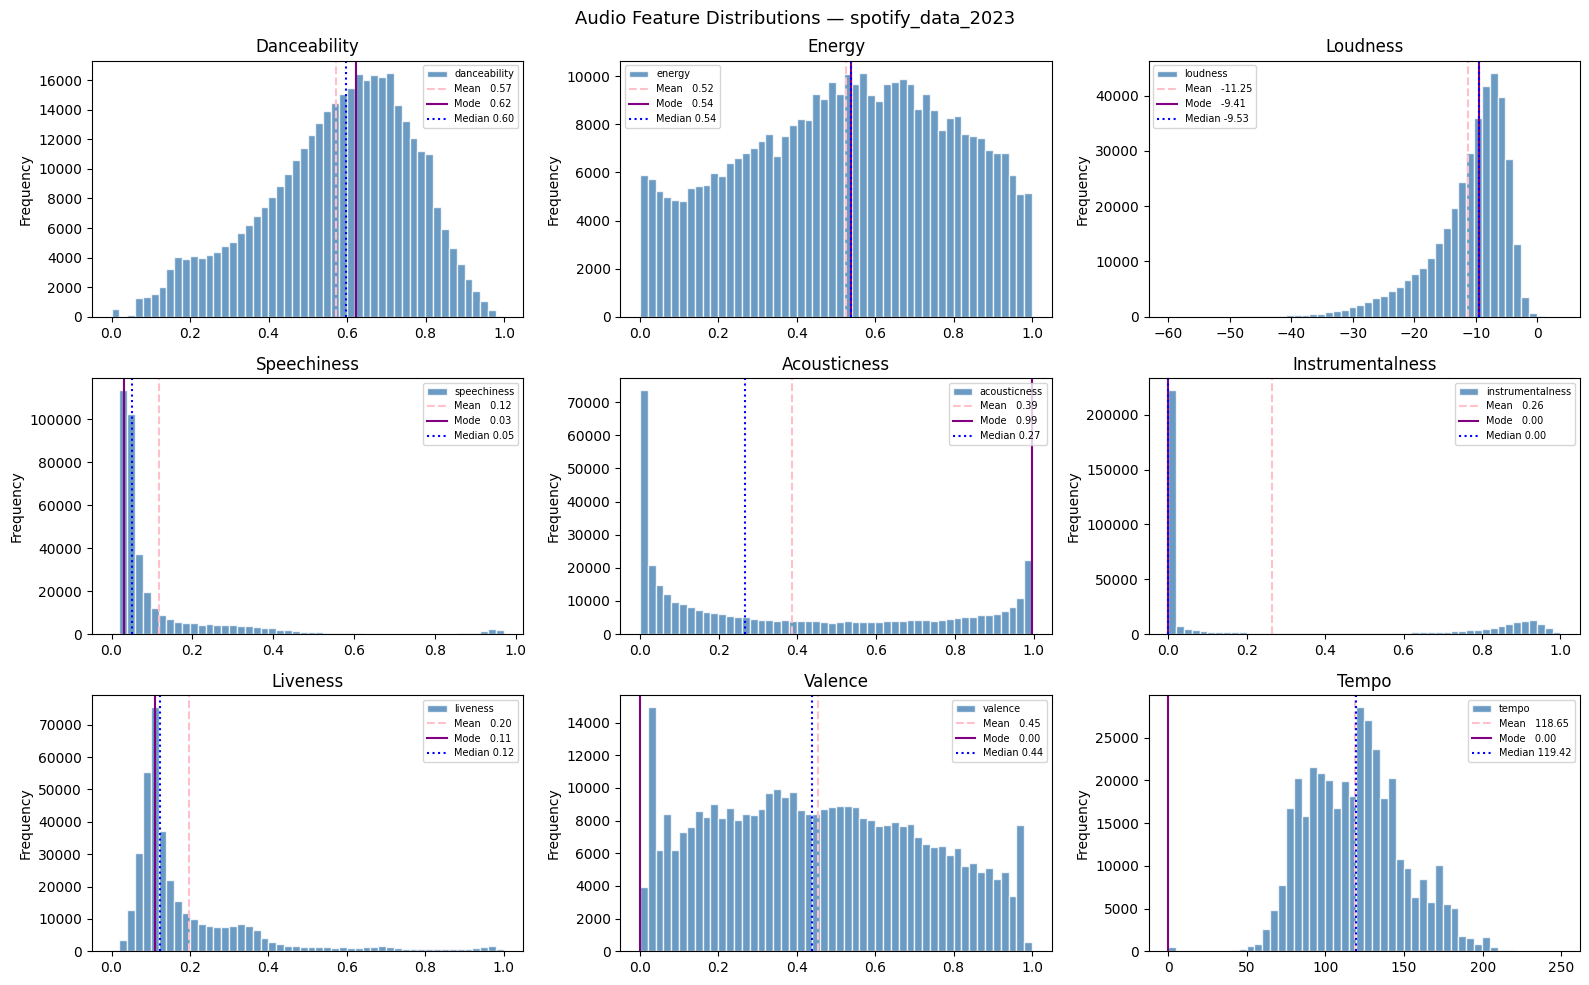

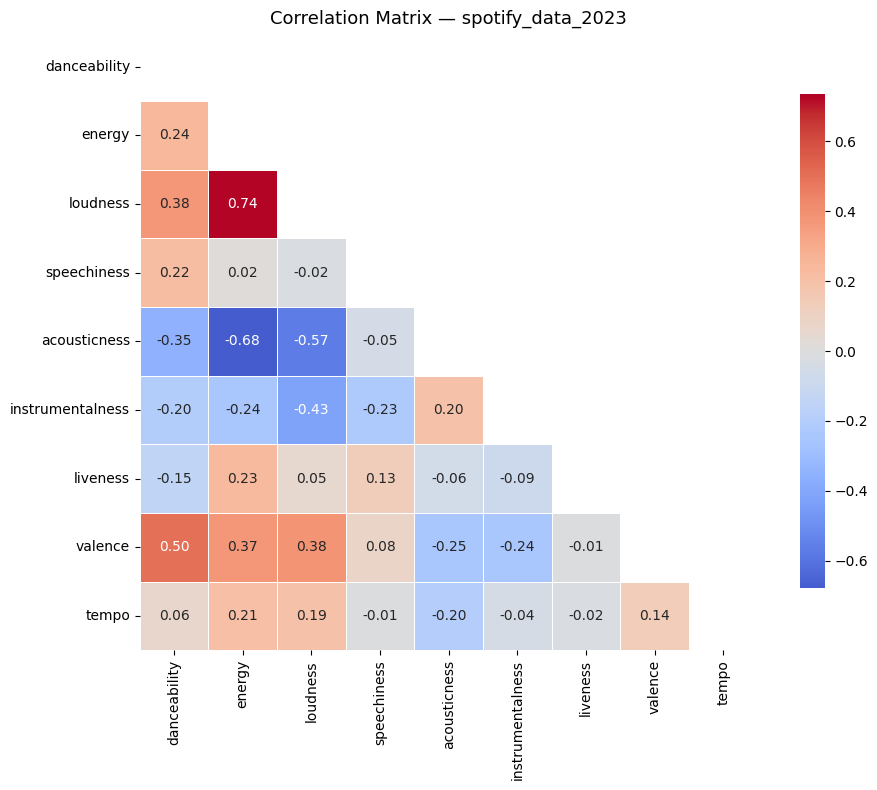


─────────────────────────────────────────────────────────────────


_________________________________________________________________

📊📊📊 DATASET  : audio_features_apr2019

_________________________________________________________________

 Shape: 130,663 rows x 17 cols

 Columns & Data Types:
  Column                                   Dtype
  ---------------------------------------------
  artist_name                                str
  track_id                                   str
  track_name                                 str
  acousticness                           float64
  danceability                           float64
  duration_ms                              int64
  energy                                 float64
  instrumentalness                       float64
  key                                      int64
  liveness                               float64
  loudness                               float64
  mode                                     int64
  speechiness     

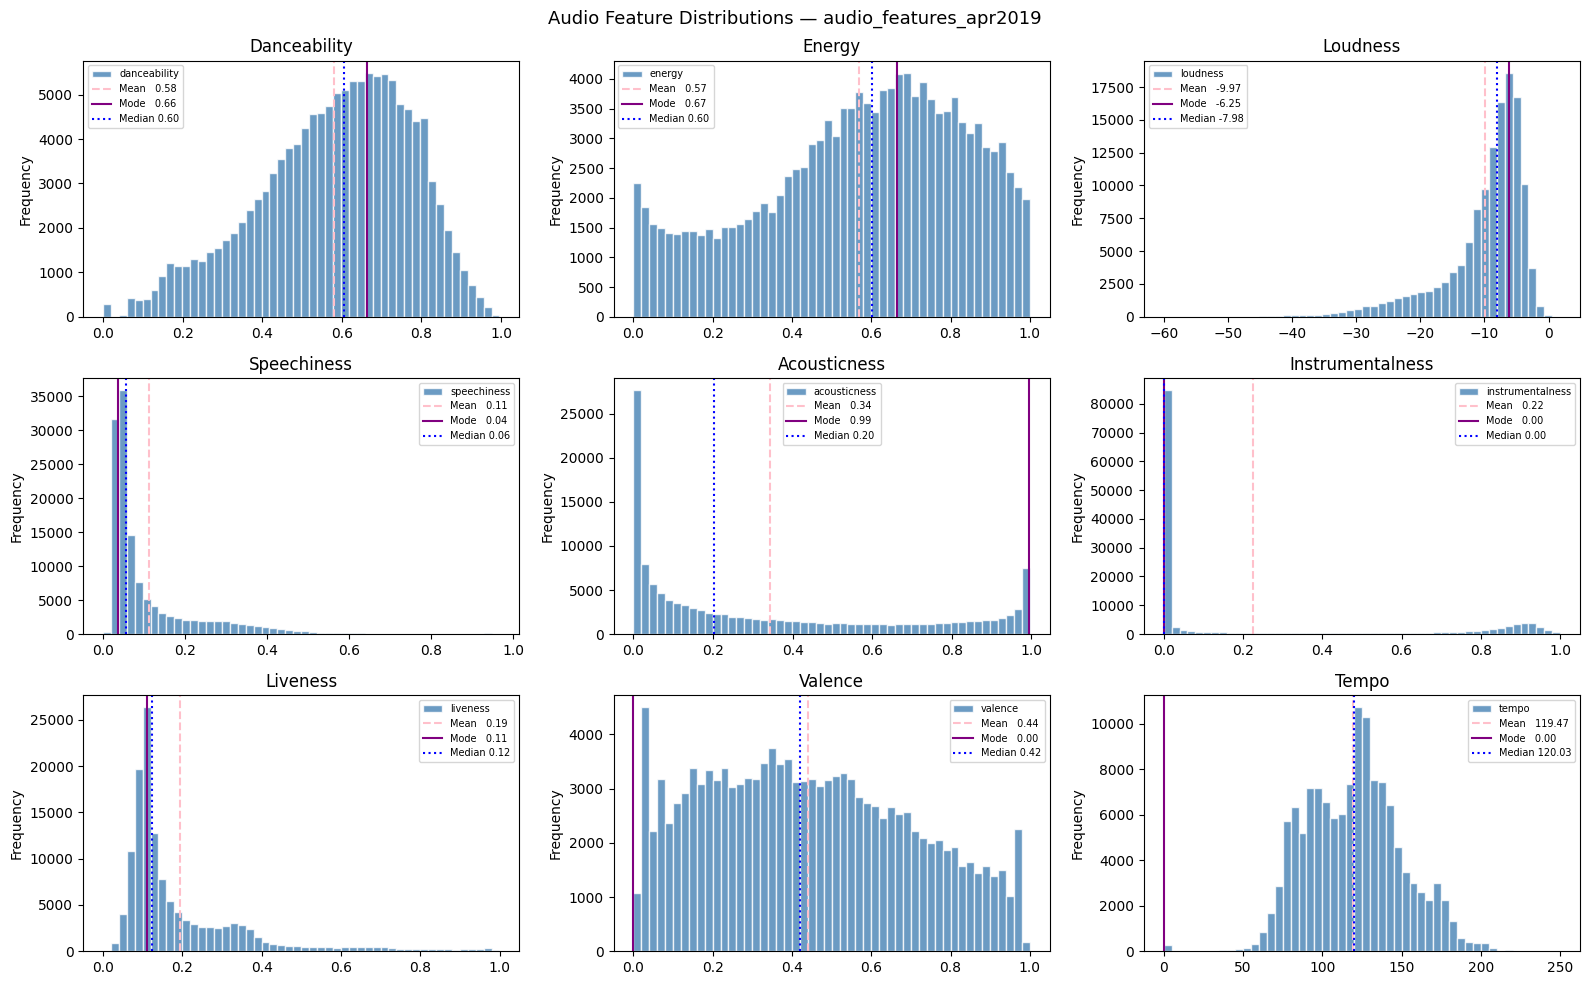

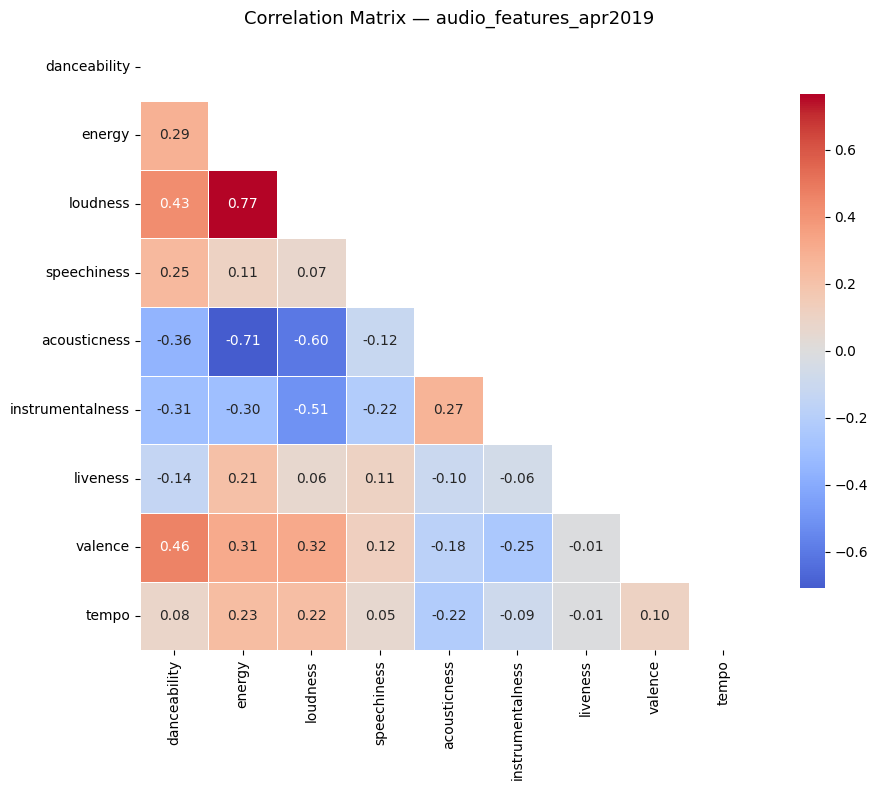


─────────────────────────────────────────────────────────────────


_________________________________________________________________

📊📊📊 DATASET  : audio_features_nov2018

_________________________________________________________________

 Shape: 116,372 rows x 17 cols

 Columns & Data Types:
  Column                                   Dtype
  ---------------------------------------------
  artist_name                                str
  track_id                                   str
  track_name                                 str
  acousticness                           float64
  danceability                           float64
  duration_ms                              int64
  energy                                 float64
  instrumentalness                       float64
  key                                      int64
  liveness                               float64
  loudness                               float64
  mode                                     int64
  speechiness     

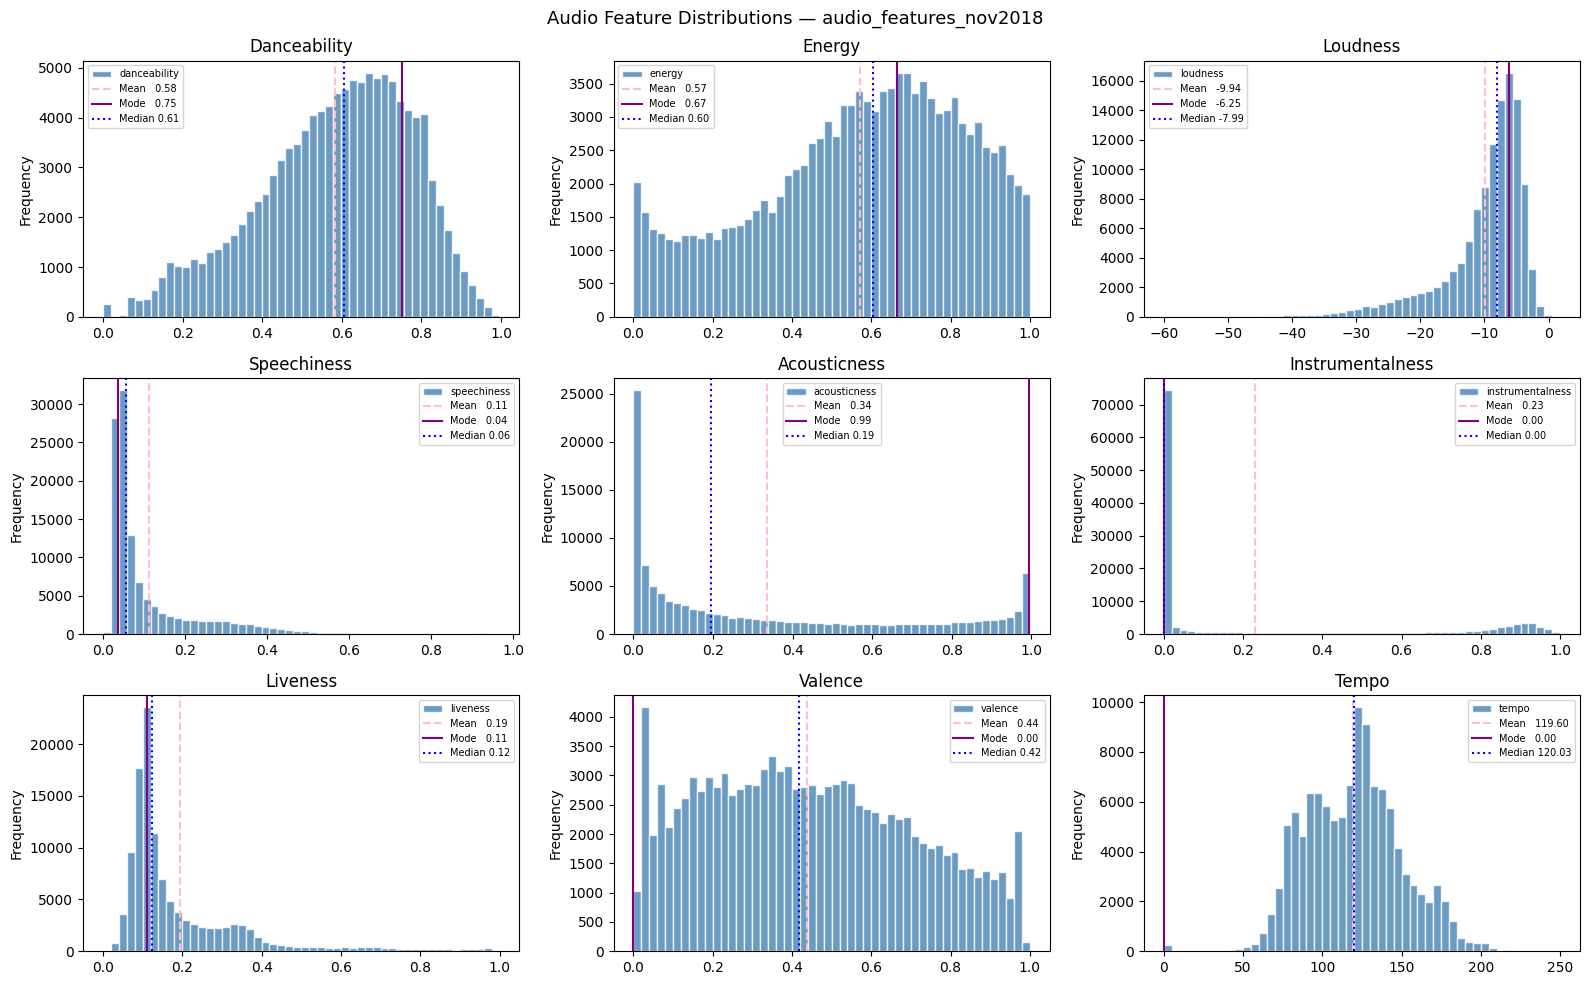

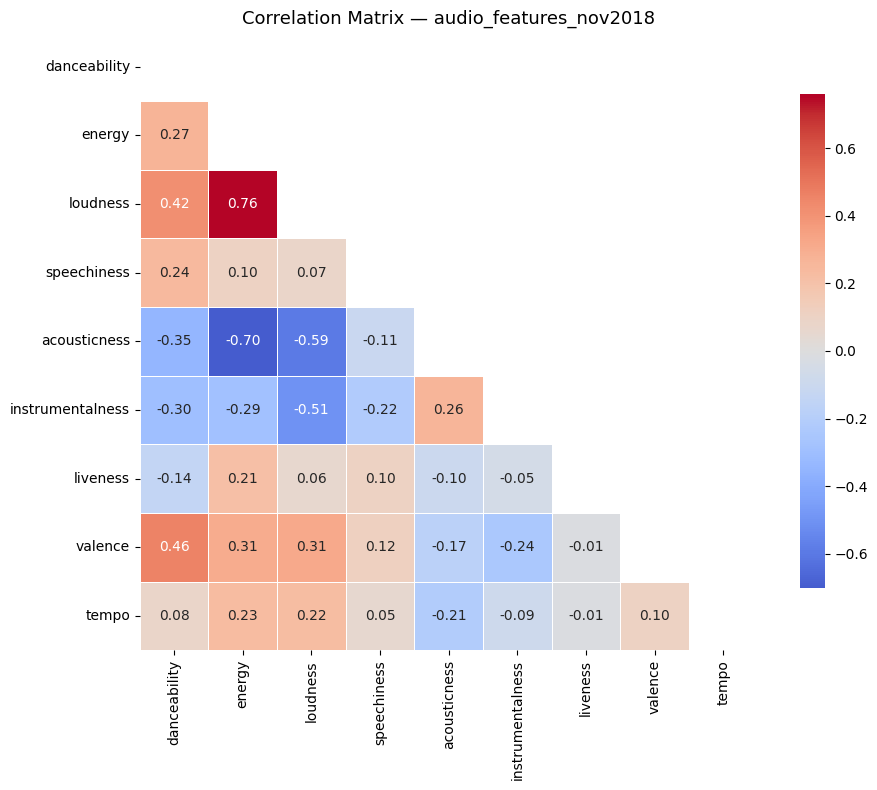


─────────────────────────────────────────────────────────────────


_________________________________________________________________

📊📊📊 DATASET  : spotify_tracks

_________________________________________________________________

 Shape: 114,000 rows x 21 cols

 Columns & Data Types:
  Column                                   Dtype
  ---------------------------------------------
  Unnamed: 0                               int64
  track_id                                   str
  artists                                    str
  album_name                                 str
  track_name                                 str
  popularity                               int64
  duration_ms                              int64
  explicit                                  bool
  danceability                           float64
  energy                                 float64
  key                                      int64
  loudness                               float64
  mode                    

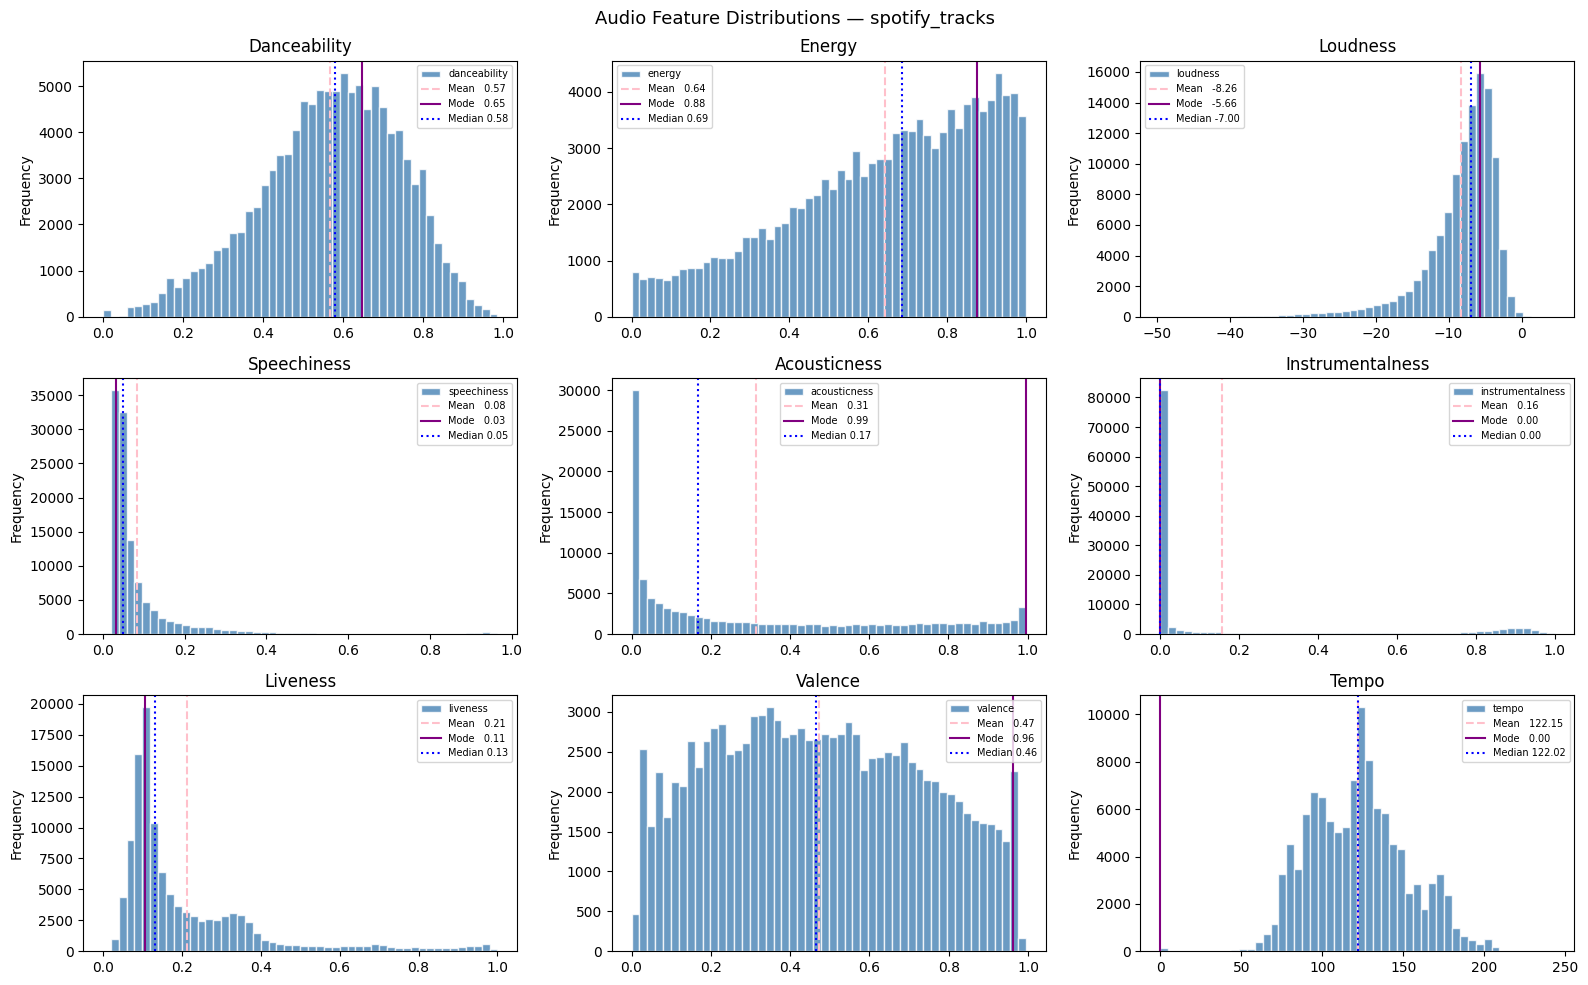

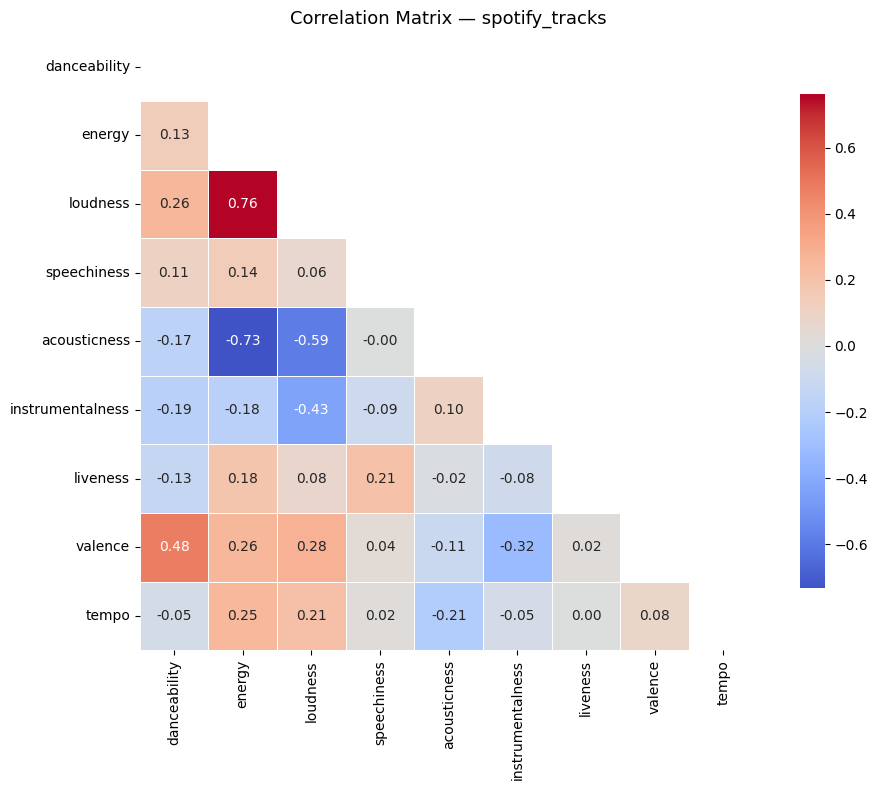


─────────────────────────────────────────────────────────────────


_________________________________________________________________

📊📊📊 DATASET  : ultimate_spotify_tracks

_________________________________________________________________

 Shape: 232,725 rows x 18 cols

 Columns & Data Types:
  Column                                   Dtype
  ---------------------------------------------
  genre                                      str
  artist_name                                str
  track_name                                 str
  track_id                                   str
  popularity                               int64
  acousticness                           float64
  danceability                           float64
  duration_ms                              int64
  energy                                 float64
  instrumentalness                       float64
  key                                        str
  liveness                               float64
  loudness       

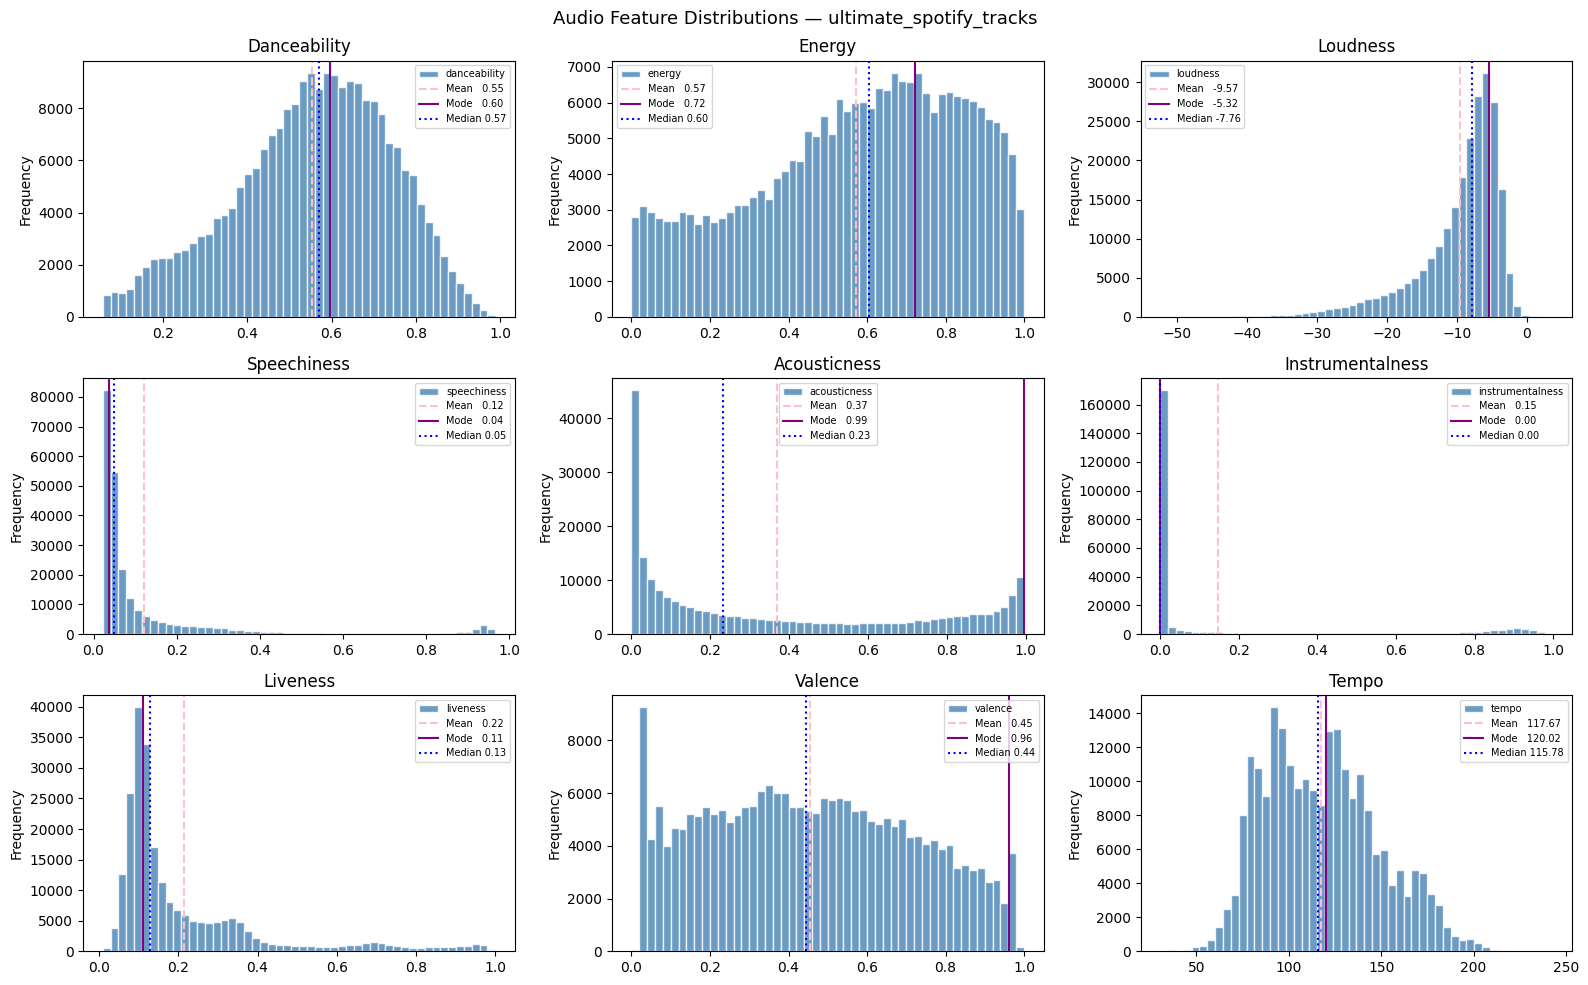

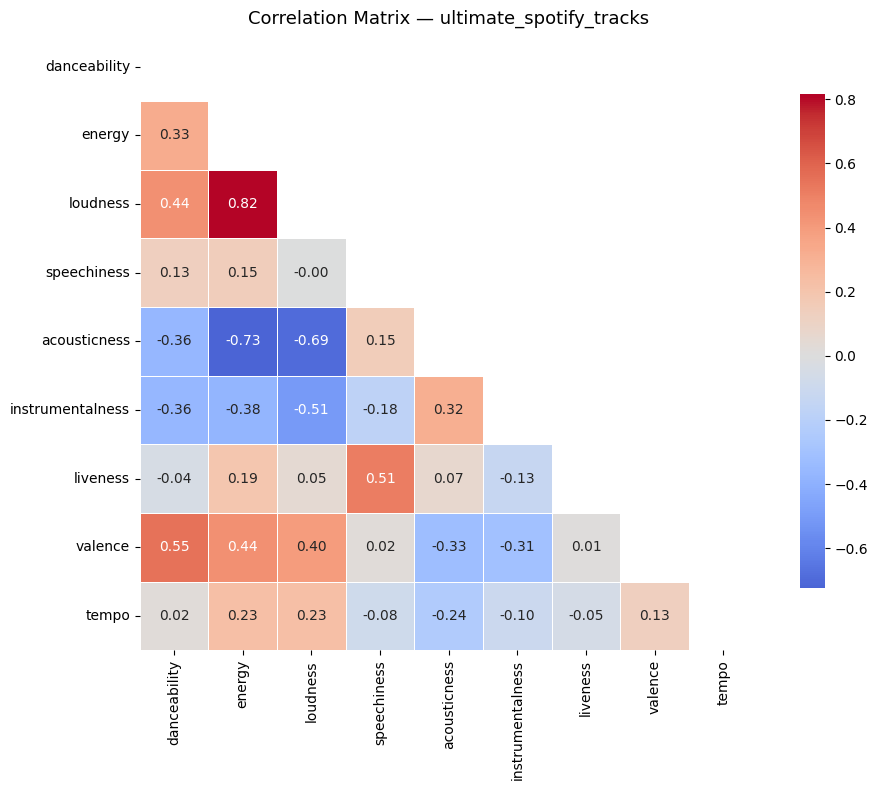


─────────────────────────────────────────────────────────────────



In [10]:
# ── EDA per Dataset ──────────────────────────────────────────────

for name, df in datasets.items():
    print(f'\n{"_"*65}')
    print(f'\n📊📊📊 DATASET  : {name}')
    print(f'\n{"_"*65}')

    # ── 1. Shape ────────────────────────────────────────────────
    print(f'\n Shape: {df.shape[0]:,} rows x {df.shape[1]} cols')

    # ── 2. Columns & Data Types ─────────────────────────────────
    print(f'\n Columns & Data Types:')
    print(f'  {"Column":<35} {"Dtype":>10}')
    print(f'  {"-"*45}')
    for col, dtype in df.dtypes.items():
        print(f'  {col:<35} {str(dtype):>10}')

    # ── 4. Missing Values ────────────────────────────────────────
    print(f'\n Missing Values:')
    missing = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)
    missing = missing[missing > 0]
    if missing.empty:
        print(' No missing values')
    else:
        print(f'  {"Column":<35} {"Count":>10} {"Pct":>8}')
        print(f'  {"-"*55}')
        for col, pct in missing.items():
            count = df[col].isnull().sum()
            print(f'  {col:<35} {count:>10,} {pct:>7.2f}%')

    # ── 5. Duplicates ────────────────────────────────────────────
    dupes = df.duplicated().sum()
    print(f'\n Duplicate rows: {dupes:,} ({dupes/len(df)*100:.2f}%)')

    # ── 6. Statistics for Audio Features ────────────────────────
    available = [f for f in AUDIO_FEATURES if f in df.columns]
    if available:
        print(f'\n  Audio Feature Statistics:')
        print(f'  {"Feature":<20} {"Mean":>8} {"Mode":>8} {"Median":>8} {"Std":>8} {"Min":>8} {"Max":>8}')
        print(f'  {"-"*68}')
        for feature in available:
            data   = df[feature].dropna()
            mean   = data.mean()
            mode   = data.mode()[0]
            median = data.median()
            std    = data.std()
            mn     = data.min()
            mx     = data.max()
            print(f'  {feature:<20} {mean:>8.3f} {mode:>8.3f} {median:>8.3f} {std:>8.3f} {mn:>8.3f} {mx:>8.3f}')

    # ── 7. Feature Distribution Plots ───────────────────────────
    if available:
        n = len(available)
        fig, axes = plt.subplots(3, 3, figsize=(16, 10))
        axes = axes.flatten()

        for ax, feature in zip(axes, available):
            data   = df[feature].dropna()
            mean   = data.mean()
            mode   = data.mode()[0]
            median = data.median()

            data.plot(kind='hist', bins=50, ax=ax, color='steelblue', edgecolor='white', alpha=0.8)
            ax.axvline(mean,   color='pink',    linestyle='--', linewidth=1.5, label=f'Mean   {mean:.2f}')
            ax.axvline(mode,   color='purple',  linestyle='-',  linewidth=1.5, label=f'Mode   {mode:.2f}')
            ax.axvline(median, color='blue', linestyle=':',  linewidth=1.5, label=f'Median {median:.2f}')
            ax.set_title(feature.capitalize())
            ax.legend(fontsize=7)

        # hide unused subplots
        for ax in axes[n:]:
            ax.set_visible(False)

        plt.suptitle(f'Audio Feature Distributions — {name}', fontsize=13)
        plt.tight_layout()
        plt.savefig(PLOTS / f'distributions_{name}.png', dpi=150, bbox_inches='tight')
        plt.show()

    # ── 9. Correlation Heatmap ──────────────────────────────────
    if len(available) > 1:
        corr = df[available].corr()
        plt.figure(figsize=(10, 8))
        mask = np.triu(np.ones_like(corr, dtype=bool))
        sns.heatmap(
            corr, mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', center=0, square=True,
            linewidths=0.5, cbar_kws={'shrink': 0.8}
        )
        plt.title(f'Correlation Matrix — {name}', fontsize=13)
        plt.tight_layout()
        plt.savefig(PLOTS / f'correlation_{name}.png', dpi=150, bbox_inches='tight')
        plt.show()

    print(f'\n{"─"*65}\n')

#Notes:

- we noticed that loudness and energy are very corellated , we're dropping loudness
- as we have nearly the same columns in each tracks datasets, we're standarizing the columns and merging the all the datasets and cleaning them all to be a larger dataset to work with
